# 12: SHAP mechanism check for the residual CatBoost model

** CatBoost model now predicts a **residual** (`log_attendance - linear_pred`), not raw log-attendance, and `metro_size` is no longer one of its features at all

- There is no more `metro_size` SHAP value
- The RBA-vs-Etihad shift is now **(linear stage's deterministic contribution) + (CatBoost
  residual SHAP for every remaining feature)**, not pure CatBoost SHAP. The linear contribution
  is added as one extra, clearly-labeled bar/segment below, not a SHAP value.
- `base_value + sum(phi_i)` reconstructs the **residual**, not raw log-attendance so read the
  waterfall plot accordingly.
- Separately: `venue_name="Etihad Park"` is still an unseen category for CatBoost (ordinary
  categorical unseen-level handling) 

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from catboost import CatBoostRegressor

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")

CAT_FEATURES = ["day_of_week", "venue_name", "home_team", "away_team"]
NEW_COLS = ['ppg', 'points_back_from_playoff_line', 'temp_max_c', 'precipitation_mm', 'stop_count_catchment', 'pct_commute_transit', 'prior_sellout_rate']  # ppg/playoff-distance/weather/transit-dependence/sellout-history -- see 11
NUM_FEATURES = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
                 "stadium_capacity", "dedicated_soccer_facility", "shared_with_other_league",
                 "team_venue_tenure", "team_league_tenure"] + NEW_COLS  # metro_size excluded -- see intro
FEATURES = CAT_FEATURES + NUM_FEATURES

catboost_model = CatBoostRegressor()
catboost_model.load_model(os.path.join(OUTPUT_DIR, "catboost_attendance_model.cbm"))

coef_table = pd.read_csv(os.path.join(OUTPUT_DIR, "attendance_linear_model_coefficients.csv")).set_index("predictor")
LINEAR_INTERCEPT = coef_table.loc["Intercept", "coef"]
LINEAR_COEF = coef_table.loc["log_metro_size", "coef"]


def linear_pred(metro_size):
    return LINEAR_INTERCEPT + LINEAR_COEF * np.log(metro_size)


df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "catboost_training_table.csv"))

# Sports Illustrated Stadium's real venue features (most recent 2026 game)
gotham_rba = df[(df["home_team"] == "NJ/NY Gotham FC") & df["stadium_capacity"].notna() & (df["year"] == 2026)]
rba_venue = gotham_rba.sort_values("date_time_utc").iloc[-1] if "date_time_utc" in df.columns else gotham_rba.iloc[-1]
RBA_METRO_SIZE = rba_venue["metro_size"]
RBA_FEATURES = {
    "venue_name": "Sports Illustrated Stadium", "stadium_capacity": rba_venue["stadium_capacity"],
    "dedicated_soccer_facility": rba_venue["dedicated_soccer_facility"],
    "shared_with_other_league": rba_venue["shared_with_other_league"],
    "team_venue_tenure": rba_venue["team_venue_tenure"],
    "team_league_tenure": rba_venue["team_league_tenure"],
    **{col: rba_venue[col] for col in NEW_COLS},
}

# Etihad Park's real venue features and the opponent x day synthetic grid pulled from notebook 11.
etihad_row = pd.read_csv(os.path.join(OUTPUT_DIR, "etihad_venue_features.csv")).iloc[0].to_dict()
ETIHAD_METRO_SIZE = etihad_row["metro_size"]
ETIHAD_FEATURES = {k: v for k, v in etihad_row.items() if k != "metro_size"}
ETIHAD_FEATURES["team_venue_tenure"] = 0
# Gotham (formerly Sky Blue FC) is a 2013 founding-era team -- see 09's FOUNDING_YEAR_OVERRIDE --
# so this is a real, in-range value (13, matching this team's own observed training max), not NaN.
ETIHAD_FEATURES["team_league_tenure"] = 2026 - 2013
base_rows = pd.read_csv(os.path.join(OUTPUT_DIR, "gotham_synthetic_grid_base.csv")).to_dict("records")

print(f"Sports Illustrated Stadium venue features (CatBoost, metro_size excluded): {RBA_FEATURES}")
print(f"Etihad Park venue features (CatBoost, metro_size excluded): {ETIHAD_FEATURES}")
print(f"Linear-stage metro_size: RBA={RBA_METRO_SIZE:,.0f}, Etihad={ETIHAD_METRO_SIZE:,.0f}")

rba_rows = pd.DataFrame([{**r, **RBA_FEATURES} for r in base_rows])
etihad_rows = pd.DataFrame([{**r, **ETIHAD_FEATURES} for r in base_rows])
for c in CAT_FEATURES:
    rba_rows[c] = rba_rows[c].astype(str)
    etihad_rows[c] = etihad_rows[c].astype(str)

print(f"\n{len(rba_rows)} paired rows each (RBA vs Etihad), all non-venue features held identical")

explainer = shap.TreeExplainer(catboost_model)
shap_values_rba = explainer(rba_rows[FEATURES])
shap_values_etihad = explainer(etihad_rows[FEATURES])

Sports Illustrated Stadium venue features (CatBoost, metro_size excluded): {'venue_name': 'Sports Illustrated Stadium', 'stadium_capacity': np.float64(25000.0), 'dedicated_soccer_facility': np.int64(1), 'shared_with_other_league': np.int64(1), 'team_venue_tenure': np.float64(4.0), 'team_league_tenure': np.float64(13.0), 'ppg': np.float64(2.0), 'points_back_from_playoff_line': np.int64(-10), 'temp_max_c': np.float64(29.0), 'precipitation_mm': np.float64(0.6), 'stop_count_catchment': np.float64(16.0), 'pct_commute_transit': np.float64(29.561552945395857), 'prior_sellout_rate': np.float64(0.0)}
Etihad Park venue features (CatBoost, metro_size excluded): {'venue_name': 'Etihad Park', 'stadium_capacity': 25000, 'dedicated_soccer_facility': 1, 'shared_with_other_league': 1, 'ppg': 2.0, 'points_back_from_playoff_line': -10, 'temp_max_c': 24.2, 'precipitation_mm': 0.1, 'stop_count_catchment': nan, 'pct_commute_transit': 45.554923996280095, 'prior_sellout_rate': 0.0, 'team_venue_tenure': 0, 'te

## Global importance (residual-stage), RBA and Etihad

This ranks what drives the **residual** i.e. what's left to explain after accessibility's
effect has already been pulled out by the linear stage. `metro_size` will not appear; that's by
design, not a finding that accessibility doesn't matter.

Linear-stage shift (Etihad vs RBA, log-attendance): +0.1973
CatBoost residual-stage shift (mean): +0.0472
Net change, Etihad vs RBA (combined model, mean predicted log-attendance): +0.2445 (+27.7%)


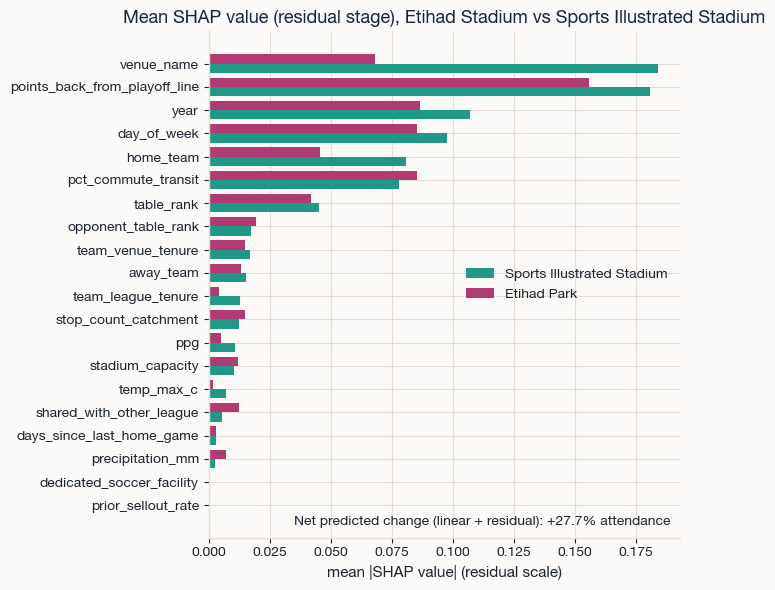

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

mean_abs_rba = pd.Series(np.abs(shap_values_rba.values).mean(axis=0), index=FEATURES)
mean_abs_etihad = pd.Series(np.abs(shap_values_etihad.values).mean(axis=0), index=FEATURES)
order = mean_abs_rba.sort_values(ascending=False).index

y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(y + 0.2, mean_abs_rba[order], height=0.4, color=NWSL_PALETTE[2], label="Sports Illustrated Stadium")
ax.barh(y - 0.2, mean_abs_etihad[order], height=0.4, color=NWSL_PALETTE[3], label="Etihad Park")
ax.set_yticks(y, order)
ax.invert_yaxis()
ax.set_xlabel("mean |SHAP value| (residual scale)")
ax.legend()

# Net change = linear component's shift + CatBoost residual's shift (NOT catboost_model.predict
# alone -- that only reconstructs the residual now, not the full log-attendance prediction).
linear_shift_log = linear_pred(ETIHAD_METRO_SIZE) - linear_pred(RBA_METRO_SIZE)
resid_pred_rba = catboost_model.predict(rba_rows[FEATURES])
resid_pred_etihad = catboost_model.predict(etihad_rows[FEATURES])
resid_shift_log = resid_pred_etihad.mean() - resid_pred_rba.mean()
net_change_log = linear_shift_log + resid_shift_log
net_change_pct = np.exp(net_change_log) - 1
print(f"Linear-stage shift (Etihad vs RBA, log-attendance): {linear_shift_log:+.4f}")
print(f"CatBoost residual-stage shift (mean): {resid_shift_log:+.4f}")
print(f"Net change, Etihad vs RBA (combined model, mean predicted log-attendance): "
      f"{net_change_log:+.4f} ({net_change_pct:+.1%})")
ax.text(0.98, 0.02, f"Net predicted change (linear + residual): {net_change_pct:+.1%} attendance",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10, fontweight="bold")
plt.title("Mean SHAP value (residual stage), Etihad Stadium vs Sports Illustrated Stadium")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_rba_etihad_comparison.png"), dpi=150)
plt.show()

### Beeswarm plots: direction + spread, residual-stage SHAP (Etihad rows)

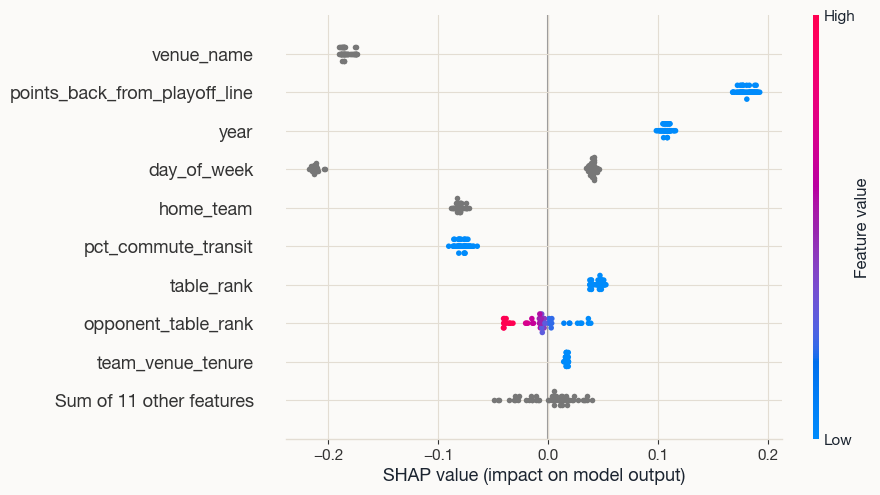

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


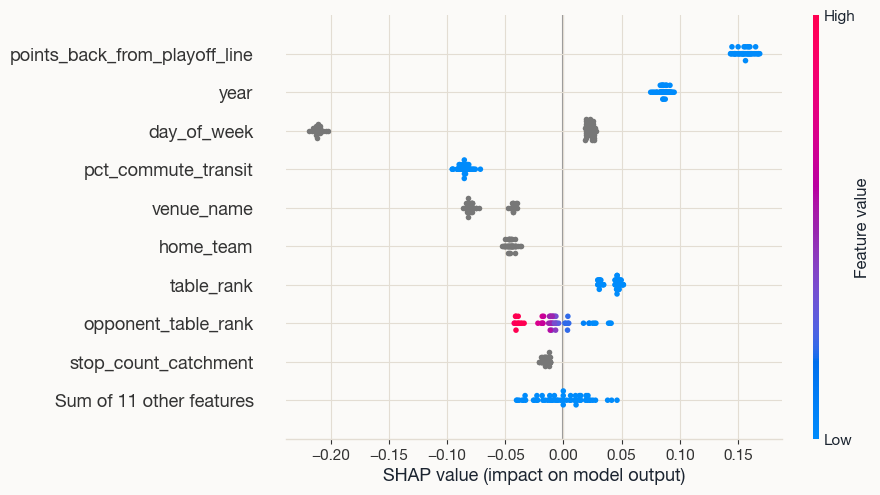

In [3]:
shap.plots.beeswarm(shap_values_rba, max_display=10)
shap.plots.beeswarm(shap_values_etihad, max_display=10)

### Waterfall plot: one row, Etihad Park

`base_value + sum(phi_i)` reconstructs this model's own output, which is the **residual**, not
raw log-attendance -- the linear stage's contribution (a single deterministic number, not a SHAP
value) still needs to be added on top to get the actual predicted attendance; see `11`'s Queens
counterfactual section for that combination.

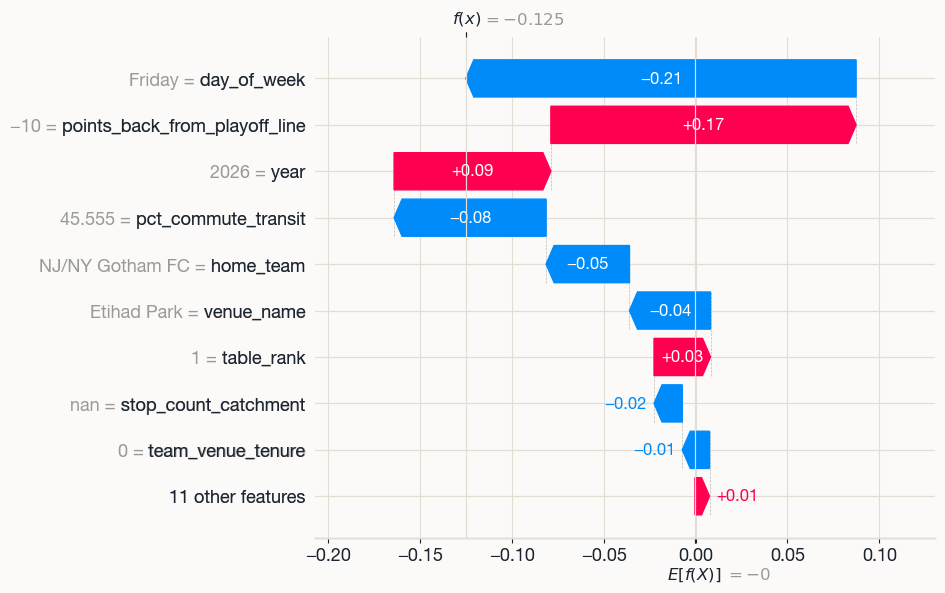


Additivity check (Etihad row 0, residual scale):
base + sum(phi_i):  -0.1249
model prediction:   -0.1249
match: True


In [4]:
shap.plots.waterfall(shap_values_etihad[0], max_display=10)

row = 0
reconstructed = shap_values_etihad.base_values[row] + shap_values_etihad.values[row].sum()
actual = catboost_model.predict(etihad_rows[FEATURES].iloc[[row]])[0]
print(f"\nAdditivity check (Etihad row {row}, residual scale):")
print(f"base + sum(phi_i):  {reconstructed:.4f}")
print(f"model prediction:   {actual:.4f}")
print(f"match: {np.isclose(reconstructed, actual)}")

## What's driving the RBA -> Etihad shift: linear component + residual SHAP, summed

Not pure CatBoost SHAP -- the linear stage's accessibility contribution is added as its own
labeled bar, since it's the actual dominant driver of the shift and isn't a SHAP value at all.
Separately, worth flagging: `venue_name="Etihad Park"` is an unseen category for CatBoost here
(ordinary categorical unseen-level handling) -- a smaller, different caveat than the metro_size
extrapolation issue this restructuring fixes.

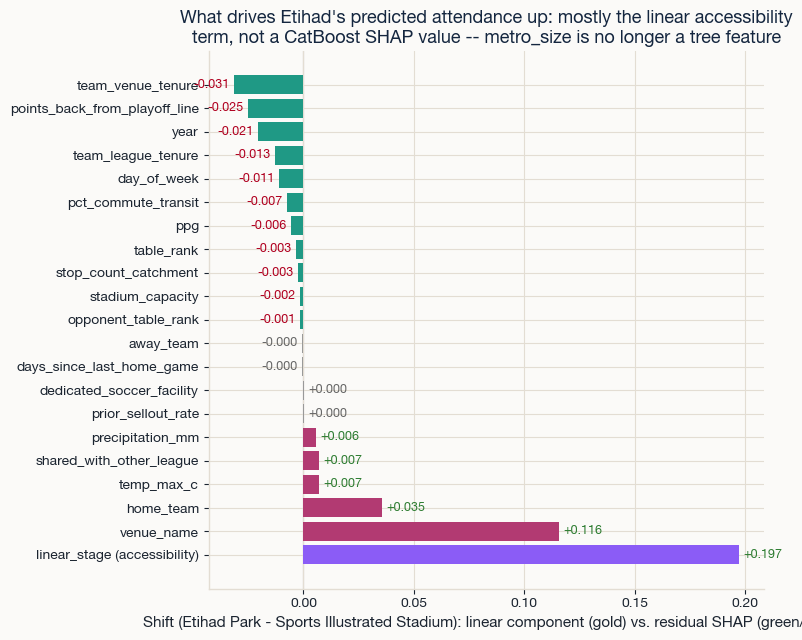

In [5]:
shap_shift = pd.Series(shap_values_etihad.values.mean(axis=0) - shap_values_rba.values.mean(axis=0), index=FEATURES)
shap_shift["linear_stage (accessibility)"] = linear_shift_log
shap_shift = shap_shift.sort_values()

ZERO_TOL = 0.001

def bar_color(v, name):
    if name == "linear_stage (accessibility)":
        return NWSL_PALETTE[4]
    if abs(v) < ZERO_TOL:
        return "#999999"
    return NWSL_PALETTE[3] if v >= 0 else NWSL_PALETTE[2]

def text_color(v):
    if abs(v) < ZERO_TOL:
        return "#666666"
    return "#2E7D32" if v >= 0 else "#B00020"

y = np.arange(len(shap_shift))
colors = [bar_color(v, n) for n, v in shap_shift.items()]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(y, shap_shift.values, color=colors)
ax.axvline(0, color="#888888", lw=0.8, zorder=0)
ax.set_yticks(y, shap_shift.index)
ax.invert_yaxis()
ax.set_xlabel("Shift (Etihad Park - Sports Illustrated Stadium): linear component (gold) vs. residual SHAP (green/red)")
ax.set_title("What drives Etihad's predicted attendance up: mostly the linear accessibility\nterm, not a CatBoost SHAP value -- metro_size is no longer a tree feature")

for yi, (name, v) in zip(y, shap_shift.items()):
    ax.text(v + (0.002 if v >= 0 else -0.002), yi, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9,
            color=text_color(v), fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_shift_diverging.png"), dpi=150)
plt.show()